<center>
  <h2>Prelims 2024</h2>
  <h3>Mani Tyagi</h3>
  <h4>200973108</h4>
</center>

In [21]:
# importing libraries
import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial import legendre as leg
from numpy.polynomial import hermite as herm
import random
import time
from mpl_toolkits.mplot3d import Axes3D


### Part (a)

An ellipsoid is defined by the equation:
$$
\frac{x^2}{a^2} + \frac{y^2}{b^2} + \frac{z^2}{c^2} < 1
$$
where $a$, $b$, and $c$ are the semi-axis lengths along the $x$, $y$, and $z$ axes, respectively.

The exact volume $V_{\text{exact}}$ of the ellipsoid is given by:
$$
V_{\text{exact}} = \frac{4}{3} \pi a b c
$$

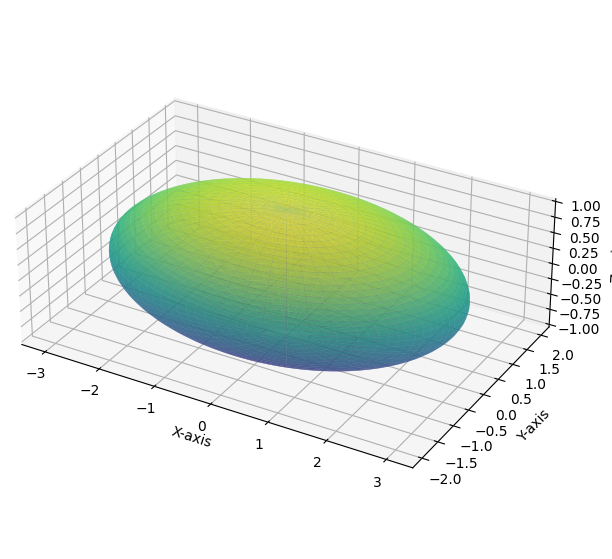

In [22]:
# Semi-axis lengths
a = 3
b = 2
c = 1

# Create a grid of points
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = a * np.outer(np.cos(u), np.sin(v))
y = b * np.outer(np.sin(u), np.sin(v))
z = c * np.outer(np.ones_like(u), np.cos(v))

# Plot the ellipsoid with enhanced colors
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Use a colormap
ax.plot_surface(x, y, z, cmap='viridis', edgecolor='none', alpha=0.7)

# Labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')

# Set equal aspect ratio
ax.set_box_aspect([a, b, c])
ax.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
ax.set_facecolor('white')

plt.show()


The domain to be considers goes from -a to a in x-direction, -b to b in y-direction and -c to c in z-direction. Hence, the volume of the bounding box of the ellipsoid is:
$$
V_{\text{box}} = 8abc
$$
To estimate the volume using the Monte Carlo method, I am using the following steps:
- Generate $N$ random points uniformly distributed within the bounding box:
$$
x \sim \mathcal{U}(-a, a), \quad y \sim \mathcal{U}(-b, b), \quad z \sim \mathcal{U}(-c, c)
$$
where $\mathcal{U}$ denotes a uniform distribution.
- Count the number of points $k$ that lie inside the ellipsoid:
$$
\frac{x^2}{a^2} + \frac{y^2}{b^2} + \frac{z^2}{c^2} < 1
$$

- The estimated volume $V_{\text{est}}$ of the ellipsoid is calculated as:
$$
V_{\text{est}} = V_{\text{box}} \times \frac{k}{N} = 8abc \times \frac{k}{N}
$$

Given the parameters $a = 3.0$, $b = 2.0$, $c = 1.0$, the exact volume of the ellipsoid is:
$$
V_{\text{exact}} = \frac{4}{3} \pi (3.0) (2.0) (1.0) = \frac{8}{3} \pi \approx 8.37758
$$

$NOTE:$ The results in this part are generated using the C++ code: Q4_a.cpp. In the final report, I have used the following plot.

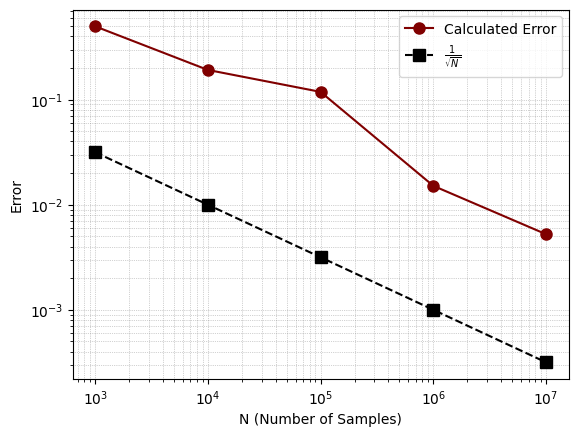

In [23]:
# Calculated data form c++ code
N = [1000, 10000, 100000, 1000000, 10000000]
errors = [0.499259, 0.191941, 0.118619, 0.0151308, 0.00524277]

# Calculate theoretical error for comparison (1/sqrt(N))
theoretical_errors = [1 / np.sqrt(n) for n in N]

# Plot the error vs N
plt.loglog(N, errors, 'o-', label='Calculated Error',color='maroon', markersize=8)
plt.loglog(N, theoretical_errors, 's--', color='black', label=r'$\frac{1}{\sqrt{N}}$', markersize=8)

# Add titles and labels
plt.xlabel('N (Number of Samples)')
plt.ylabel('Error')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)

# Show the plot
plt.show()

Following is the python code for Part(a)

In [33]:
# Function to calculate volume of ellipsoid
def calculate_volume(a, b, c, num_samples):
    """----------------------------------------------------------------
    Calculate the volume of an ellipsoid using the Monte Carlo method.

    Parameters:
    a (float): Semi-axis length along the x-axis.
    b (float): Semi-axis length along the y-axis.
    c (float): Semi-axis length along the z-axis.
    num_samples (int): Number of random samples to use for the Monte Carlo simulation.

    Returns:
    tuple: A tuple containing the estimated volume of the ellipsoid
           and the duration of the calculation in seconds.
    -------------------------------------------------------------------"""
    
    count = 0
    start_time = time.time()
    
    for _ in range(num_samples):
        x = random.uniform(-a, a)
        y = random.uniform(-b, b)
        z = random.uniform(-c, c)
        
        if (x**2)/(a**2) + (y**2)/(b**2) + (z**2)/(c**2) < 1:
            count += 1
    
    duration = time.time() - start_time
    volume = 8 * a * b * c * (count / num_samples)
    
    return volume, duration


# Main function 
def main():
    """
    Main function to calculate and print the volume of an ellipsoid for different numbers of samples.
    """
    a = 3.0
    b = 2.0
    c = 1.0
    V_exact = (4.0 / 3.0) * np.pi * a * b * c
    n_values = [1000, 10000, 100000, 1000000, 10000000]
    
    print("-" * 77)
    print(f"{'N':<12} {'Calculated Volume':<20} {'Error':<25} {'Duration (s)':<15}")
    print("-" * 77)
    
    for N in n_values:
        volume, duration = calculate_volume(a, b, c, N)
        error = abs(V_exact - volume)
        print(f"{N:<12} {volume:<20.10f} {error:<25.10f} {duration:<15.5f}")
    
    print("-" * 77)

if __name__ == "__main__":
    main()


-----------------------------------------------------------------------------
N            Calculated Volume    Error                     Duration (s)   
-----------------------------------------------------------------------------
1000         26.4000000000        1.2672587713              0.00142        
10000        25.3488000000        0.2160587713              0.01372        
100000       25.0305600000        0.1021812287              0.11705        
1000000      25.1563200000        0.0235787713              1.16587        
10000000     25.1271936000        0.0055476287              11.58876       
-----------------------------------------------------------------------------


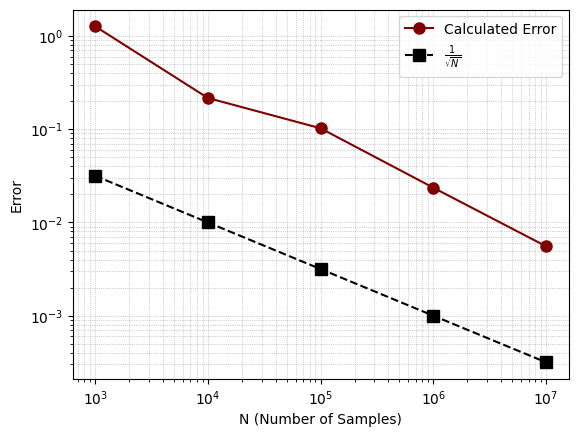

In [34]:
# Plot using python code
N = [1000, 10000, 100000, 1000000, 10000000]
errors = [1.2672587713, 0.2160587713, 0.1021812287, 0.0235787713, 0.0055476287]

# Calculate theoretical error for comparison (1/sqrt(N))
theoretical_errors = [1 / np.sqrt(n) for n in N]

# Plot the error vs N
plt.loglog(N, errors, 'o-', label='Calculated Error',color='maroon', markersize=8)
plt.loglog(N, theoretical_errors, 's--', color='black', label=r'$\frac{1}{\sqrt{N}}$', markersize=8)

# Add titles and labels
plt.xlabel('N (Number of Samples)')
plt.ylabel('Error')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)

# Show the plot
plt.show()

### Part (b)

The given integral is:
\begin{align}
    I = \int_{-5}^0 (x^2 + 1) \, dx
\end{align}

To transform the integral domain from $[-5, 0]$ to $[-1, 1]$, we use the change of variable:
$$
x = \frac{b-a}{2} t + \frac{b+a}{2}
$$
where $a = -5$ and $b = 0$. The differential $dx$ transforms as follows:
$$
dx = \frac{b-a}{2} \, dt
$$

Substituting these into the integral, we get:
\begin{align}
    I = \int_{-1}^1 \left(\left(\frac{b-a}{2} t + \frac{b+a}{2}\right)^2 + 1\right) \frac{b-a}{2} \, dt
\end{align}



To approximate the integral using Gauss-Legendre quadrature, we use the formula:
$$
\int_a^b f(x) \, dx \approx \frac{b-a}{2} \sum_{i=1}^{n} w_i f\left(\frac{b-a}{2} x_i + \frac{b+a}{2}\right)
$$
where $(x_i)$ are the roots of the Legendre polynomial $(P_n(x))$ and $(w_i)$ are the corresponding weights.

For our integral, we have $(a = -5)$ and $(b = 0)$, thus:
$$
I \approx \frac{5}{2} \sum_{i=1}^{n} w_i \left(\left(\frac{5}{2} x_i - \frac{5}{2}\right)^2 + 1\right)
$$

The exact values of $(x_i)$ and $(w_i)$ depend on the chosen $(n)$, the number of quadrature points.

In [35]:
# defining the function to be integrated
def f(x): 
    """----------------------------------------------------------------
    Function to be integrated.
    
    Parameters:
    x (float or array-like): Input value(s) at which the function is evaluated.
    
    Returns:
    float or array-like: The value of the function at x.
    -------------------------------------------------------------------"""
    return x**2 + 1

# defining function to perform Gauss legendre quadrature
def Gauss_legendre(n, a, b):
    """----------------------------------------------------------------------
    Function to approximate the integral of f(x) over the interval [a, b]
    using Gauss-Legendre quadrature with n points.
    
    Parameters:
    n (int): The number of quadrature points.
    a (float): The lower limit of the integral.
    b (float): The upper limit of the integral.
    
    Returns:
    float: The approximated value of the integral.
    --------------------------------------------------------------------------"""
    
    # initialize the sum
    sum = 0.0
    
    # Get the Gauss-Legendre nodes (xi) and weights (wi)
    xi, wi = leg.leggauss(n)
    
    # perform the summation
    for i in range(n):
        sum = sum + wi[i] * f(((b-a)/2)*xi[i] + (b+a)/2)
    
    # return the approximated value
    return ((b - a) / 2.0) * sum

In [36]:
# Define the integration limits
a = -5
b = 0

# List of different values of n
n_values = [1, 2, 3, 4, 5]

# Calculate the integral for different values of n
results = []
for n in n_values:
    integral = Gauss_legendre(n, a, b)
    results.append(integral)

# Exact value of the integral for comparison
exact_value = 46.6667
exact_value = exact_value

# Calculate errors and convergence rates
errors = [abs(result - exact_value) for result in results]

# Print the results in a formatted table
print("-" * 60)
print(f"{'n':<10} {'Calculated Integral':<25} {'Error':<25}")
print("-" * 60)
for i in range(len(n_values)):
    if i == 0:
        print(f"{n_values[i]:<10} {results[i]:<25} {errors[i]:<25}")
    else:
        print(f"{n_values[i]:<10} {results[i]:<25} {errors[i]:<25}")
print("-" * 60)

------------------------------------------------------------
n          Calculated Integral       Error                    
------------------------------------------------------------
1          36.25                     10.416699999999999       
2          46.66666666666666         3.333333334154531e-05    
3          46.66666666666666         3.333333334154531e-05    
4          46.66666666666666         3.333333334154531e-05    
5          46.66666666666668         3.333333332022903e-05    
------------------------------------------------------------


### Part (c)

Given the integral:
$$
\int_{-\infty}^{\infty} e^{-(2x-1)^2} (x^2 + 1) \, dx
$$

Substituting, $u = 2x-1$, we get the transformed Integral.

$$
I=\frac{1}{8} \int_{-\infty}^{\infty} e^{-u^2} (u^2 + 2u + 5) \, du
$$
$$\text{with, \quad}
f(u)=\frac{1}{8} (u^2 + 2u + 5)
$$
This integral is in the form of Gauss-Hermite integral.

In [37]:
# Define the function to be integrated
def integrand(u):
    """----------------------------------------------------------------
    Function to be integrated.
    
    Parameters:
    u (float or array-like): Input value(s) at which the function is evaluated.
    
    Returns:
    float or array-like: The value of the function.
    ----------------------------------------------------------------"""
    return (u**2 + 2*u + 5)/(8.0)

# Number of Gauss-Hermite nodes
n_values = [1, 2, 3, 4, 5, 6]
I_exact = 1.218562022497542   # exact value calculated using integral calculator

# Calculate the integral for different values of n
results = []
errors = []

for n in n_values:
    # Get the Gauss-Hermite nodes and weights
    nodes, weights = herm.hermgauss(n)
    
    # Calculate the integral using Gauss-Hermite quadrature
    integral = np.sum(weights * integrand(nodes))
    results.append(integral)
    
    # calculate the errors
    errors.append(np.abs(integral - I_exact))

# Print the results
print("-" * 60)
print(f"{'n':<10} {'Calculated Integral':<25} {'Error':<25}")
print("-" * 60)
for i in range(len(n_values)):
    print(f"{n_values[i]:<10} {results[i]:<25} {errors[i]:<25}")
print("-" * 60)

------------------------------------------------------------
n          Calculated Integral       Error                    
------------------------------------------------------------
1          1.1077836568159474        0.1107783656815946       
2          1.2185620224975422        2.220446049250313e-16    
3          1.2185620224975422        2.220446049250313e-16    
4          1.2185620224975422        2.220446049250313e-16    
5          1.218562022497542         0.0                      
6          1.218562022497542         0.0                      
------------------------------------------------------------
